# 05 — In-Sample / Out-of-Sample Validation

## Objective

The objective of this notebook is to evaluate whether the momentum strategy remains robust across different time periods.

We split the backtest into :

- In-sample period: 2012–2018
- Out-of-sample period: 2019–2025

The out-of-sample period is especially important because it tests the strategy on a later period that was not used for initial assessment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")
from metrics import cagr, annualized_volatility, sharpe_ratio

## 1. Load Backtest Summary
We reuse the monthly backtest summary created previously.

It contains :
- strategy returns
- strategy equity
- FEZ benchmark returns
- FEZ benchmark equity
- selected tickers



## 2. Define In-Sample and Out-of-Sample Periods
The split is defined as:
- In-sample: 2012-01-01 to 2018-12-31
- Out-of-sample: 2019-01-01 to 2025-12-31

The in-sample period is used to observe the initial behavior of the strategy.
The out-of-sample period is used to check whether the strategy remains effective in a later and independent period.

In [2]:
backtest_summary = pd.read_csv("../data/backtest_summary.csv", index_col=0, parse_dates=True)
backtest_summary.head()


is_start = "2012-01-01"
is_end = "2018-12-31"
oos_start = "2019-01-01"
oos_end = "2025-12-31"

in_sample = backtest_summary.loc[is_start:is_end].copy()
out_sample = backtest_summary.loc[oos_start:oos_end].copy()
print("In-sample period:", in_sample.index.min(), "to", in_sample.index.max())
print("Out-of-sample period:", out_sample.index.min(), "to", out_sample.index.max())
print("In-sample shape:", in_sample.shape)
print("Out-of-sample shape:", out_sample.shape)

In-sample period: 2012-01-31 00:00:00 to 2018-12-31 00:00:00
Out-of-sample period: 2019-01-31 00:00:00 to 2025-12-31 00:00:00
In-sample shape: (84, 5)
Out-of-sample shape: (84, 5)


## 3. Rebase Equity Curves
To compare periods fairly, we rebase each equity curve to 100 at the beginning of its own period.
This makes the in-sample and out-of-sample performance easier to compare visually.


## 4. In-Sample Equity Curve
This plot compares the momentum strategy and FEZ benchmark during the in-sample period.


## 5. Out-of-Sample Equity Curve
This plot compares the momentum strategy and FEZ benchmark during the out-of-sample period.
The out-of-sample result is the most important validation step because it shows whether the strategy remains effective in a later period.

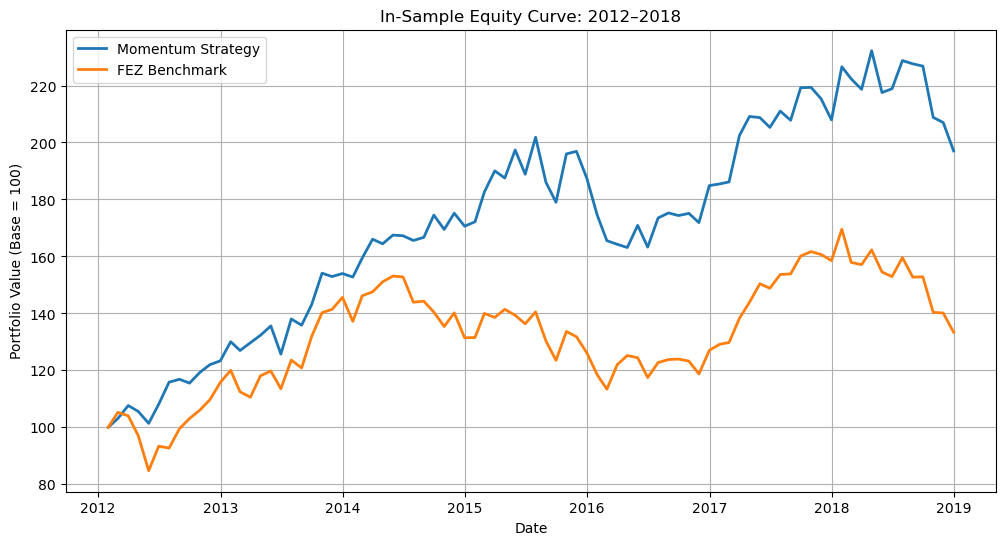

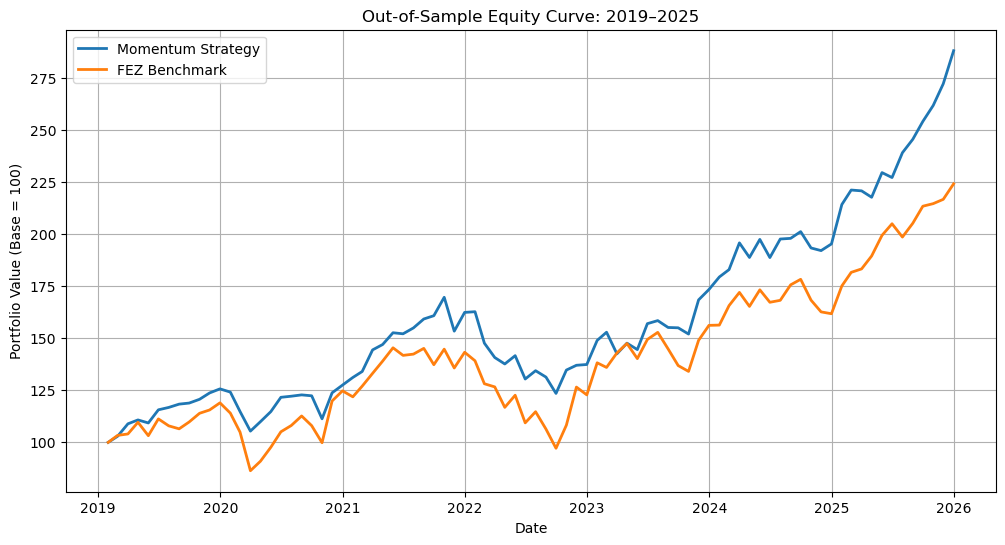

In [3]:
def rebase_equity(equity_series):
    equity_series = equity_series.dropna()
    return 100 * equity_series / equity_series.iloc[0]

in_sample_strategy_equity = rebase_equity(in_sample["Strategy Equity"])
in_sample_fez_equity = rebase_equity(in_sample["FEZ Equity"])
out_sample_strategy_equity = rebase_equity(out_sample["Strategy Equity"])
out_sample_fez_equity = rebase_equity(out_sample["FEZ Equity"])



plt.figure(figsize=(12, 6))
plt.plot(in_sample_strategy_equity, label="Momentum Strategy", linewidth=2)
plt.plot(in_sample_fez_equity, label="FEZ Benchmark", linewidth=2)
plt.title("In-Sample Equity Curve: 2012–2018")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

print()

plt.figure(figsize=(12, 6))
plt.plot(out_sample_strategy_equity, label="Momentum Strategy", linewidth=2)
plt.plot(out_sample_fez_equity, label="FEZ Benchmark", linewidth=2)
plt.title("Out-of-Sample Equity Curve: 2019–2025")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

## 6. Performance Metrics by Period

We compute CAGR, annualized volatility and Sharpe ratio separately for :

- in-sample momentum strategy
- in-sample FEZ benchmark
- out-of-sample momentum strategy
- out-of-sample FEZ benchmark

This allows us to compare the performance and risk profile across periods.

In [4]:
metrics_oos_table = pd.DataFrame({"IS Momentum Strategy": [cagr(in_sample_strategy_equity),annualized_volatility(in_sample["Strategy Return"]),sharpe_ratio(in_sample["Strategy Return"])],
                                  "IS FEZ Benchmark": [cagr(in_sample_fez_equity),annualized_volatility(in_sample["FEZ Return"]),sharpe_ratio(in_sample["FEZ Return"])],
                                  "OOS Momentum Strategy": [cagr(out_sample_strategy_equity),annualized_volatility(out_sample["Strategy Return"]),sharpe_ratio(out_sample["Strategy Return"])],
                                  "OOS FEZ Benchmark": [cagr(out_sample_fez_equity),annualized_volatility(out_sample["FEZ Return"]),sharpe_ratio(out_sample["FEZ Return"])]}, 
                                 index=["CAGR","Annualized Volatility","Sharpe Ratio"])

metrics_oos_table = metrics_oos_table.round(4)
metrics_oos_display = metrics_oos_table.copy().astype(object)
for col in metrics_oos_display.columns:
    metrics_oos_display.loc["CAGR", col] = f"{metrics_oos_table.loc['CAGR', col]:.2%}"
    metrics_oos_display.loc["Annualized Volatility", col] = f"{metrics_oos_table.loc['Annualized Volatility', col]:.2%}"
    metrics_oos_display.loc["Sharpe Ratio", col] = f"{metrics_oos_table.loc['Sharpe Ratio', col]:.2f}"
metrics_oos_display

,IS Momentum Strategy,IS FEZ Benchmark,OOS Momentum Strategy,OOS FEZ Benchmark
CAGR,10.30%,4.25%,16.52%,12.37%
Annualized Volatility,14.54%,16.33%,15.78%,20.97%
Sharpe Ratio,0.78,0.38,1.11,0.69


## 7. Interpretation

The in-sample and out-of-sample results suggest that the momentum strategy remains robust across different market periods.

During the in-sample period (2012–2018), the momentum strategy achieved a CAGR of 10.30%, compared to 4.25% for the FEZ benchmark.  
At the same time, the strategy exhibited lower annualized volatility (14.54% vs 16.33%) and a significantly higher Sharpe ratio (0.78 vs 0.38).

The out-of-sample period (2019–2025) is particularly important because it evaluates the strategy on a later and independent market environment.

During this period, the momentum strategy continued to outperform the benchmark, with:
- a CAGR of 16.52% versus 12.37% for FEZ
- lower volatility (15.78% vs 20.97%)
- a higher Sharpe ratio (1.11 vs 0.69)

These results suggest that the momentum effect remains persistent across time rather than being limited to a single market regime.

Overall, the strategy appears to generate:
- stronger returns than the benchmark
- lower risk
- superior risk-adjusted performance

The consistency between the in-sample and out-of-sample results strengthens the credibility and robustness of the momentum strategy.

## 8. Save Results

We save the in-sample and out-of-sample metrics table for reuse in the summary notebook.

In [5]:
metrics_oos_table.to_csv("../data/oos_metrics.csv")

print("File saved successfully:")
print("- ../data/oos_metrics.csv")

File saved successfully:
- ../data/oos_metrics.csv


## Conclusion

In this notebook, the momentum strategy was evaluated across two distinct and non-overlapping periods:

- In-sample: 2012–2018
- Out-of-sample: 2019–2025

The objective was to assess whether the momentum effect remained stable over time rather than being driven by a specific historical period.

The results show that the strategy outperformed the FEZ benchmark in both periods in terms of :
- annualized return (CAGR)
- volatility
- risk-adjusted performance (Sharpe ratio)

Importantly, the strategy also maintained strong results during the out-of-sample period, which increases the credibility of the momentum signal and reduces the risk of overfitting.

Overall, the analysis suggests that the momentum strategy exhibits a relatively robust performance profile across different market environments.

However, additional robustness tests and implementation constraints should still be considered before drawing definitive conclusions about real-world applicability.